# 1: Carregamento e Análise Exploratória de Imagens (EDA)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [1]:
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")
mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto'
)
print("Finalizou o processo de baixar o dataset MNIST!")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


In [2]:
X = mnist.data
y = mnist.target

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (70000, 784)
Dimensão de y: (70000,)


In [3]:
import numpy as np

y = y.astype(np.int8)

print("Classes:", np.unique(y))

Classes: [0 1 2 3 4 5 6 7 8 9]


In [5]:

distribuicao = pd.Series(y).value_counts().sort_index()

print(distribuicao)

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


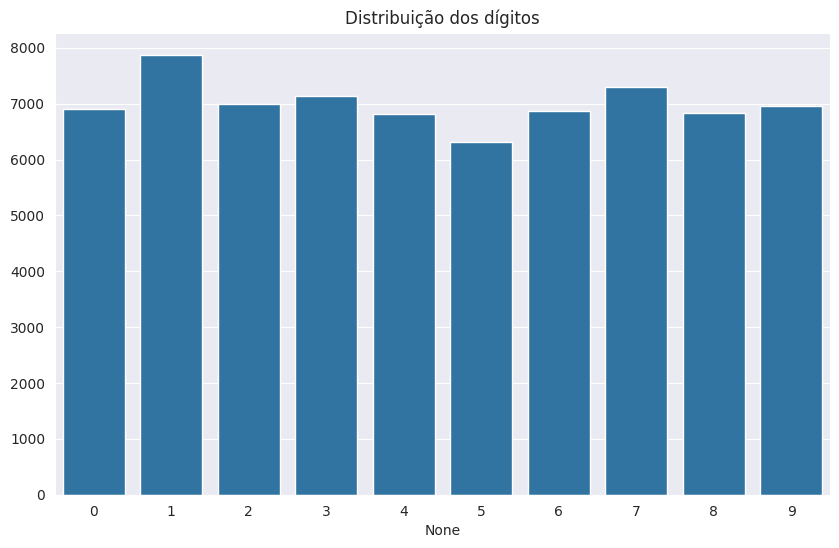

In [10]:
plt.figure(figsize=(10,6))


sns.barplot(x=distribuicao.index, y=distribuicao.values)
plt.title("Distribuição dos dígitos")

plt.show()



*   A distribuição de cada dígito é bem parecida



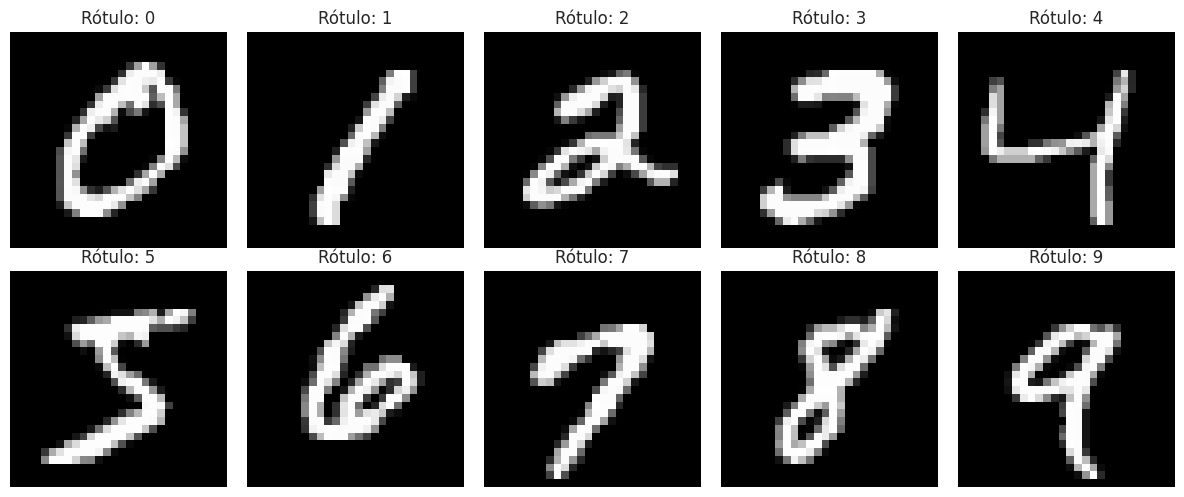

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digito in range(10):
    indice = np.where(y == digito)[0][0]

    imagem = X[indice].reshape(28, 28)

    axes[digito // 5, digito % 5].imshow(
        imagem,
        cmap='gray'
    )

    axes[digito // 5, digito % 5].set_title(f'Rótulo: {y[indice]}')
    axes[digito // 5, digito % 5].axis('off')

plt.tight_layout()
plt.show()



*   O conjunto MNIST é composto por imagens de dígitos manuscritos de 0 a 9. Cada imagem possui dimensão 28 × 28 pixels, totalizando 784 pixels.

*  No conjunto, cada imagem é representada como um vetor de 784 características, no qual cada característica corresponde à intensidade de um pixel, os valores variam de 0 a 255.


*   0 associado ao preto e 255 ao branco, com os valores intermediários representando diferentes tons de cinza. Dessa forma, a transformação de uma imagem 28 × 28 em um vetor de 784 posições permite utilizar algoritmos tradicionais de Machine Learning sobre as imagens.






# 2 Pipeline de Pré-processamento e Divisão dos Dados

## Divisão de treino e teste

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [15]:
X_train.shape

(56000, 784)

In [16]:
X_test.shape

(14000, 784)

## Normalização dos dados

In [18]:
print("Dados originais antes da normalização:")
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())

Dados originais antes da normalização:
Valor mínimo: 0
Valor máximo: 255


In [19]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Dados após a normalização:")
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())

Dados após a normalização:
Valor mínimo: 0.0
Valor máximo: 1.0





*  Para modelos baseados em distância, a normalização é importante para evitar que características com valores maiores tenham uma influência desproporcional nos cálculos de distância

*  Para modelos de Deep Learning, a normalização ajuda na otimização dos pesos durante o treinamento, tornando o processo de aprendizado mais eficiente e estável.


*   Gradientes mais estáveis: redes neurais são normalmente treinadas por métodos baseados em gradiente. Entradas em escalas muito diferentes podem gerar gradientes desproporcionais, dificultando e tornando mais lento o processo de aprendizado.

*   Funções de ativação: valores de entrada muito grandes podem fazer com que funções como Sigmoid e Tanh entrem em regiões de saturação, nas quais seus gradientes ficam muito pequenos, prejudicando o aprendizado.

*   Inicialização dos pesos: os pesos das redes neurais geralmente começam com valores relativamente pequenos. Entradas normalizadas ajudam a manter as ativações e os cálculos em escalas adequadas, reduzindo problemas numéricos e facilitando o início do treinamento.




# 3 Implementação,Treinamento e avaliação de 3 Modelos

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import time

## KNN

In [55]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
parametros_knn = {
    'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],

}




    

*  n_neighbors: Número dos K vizinhos. Determina quantos vizinhos mais próximos serão considerados para classificar uma nova observação.
*  weights: Determina como os votos desses vizinhos serão contabilizados. uniform todod os vizinhos tem o mesmo peso já em distance os vizinhos mais próximos têm maior influência.






In [71]:
knn = KNeighborsClassifier()

knn = RandomizedSearchCV(
    estimator=knn,
    param_distributions=parametros_knn,
    n_iter=5,
    cv=5,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1,
    verbose=10
)



In [72]:
inicio = time.time()

knn.fit(X_train, y_train)

fim = time.time()

tempo_treinamento_knn = fim - inicio

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [93]:
print("Melhores hiperparâmetros:")
print(knn.best_params_)

print("\nMelhor acurácia na validação cruzada:")
print(knn.best_score_)

print("\nTempo de treinamento:")
print(f"{tempo_treinamento_knn / 60:.2f} minutos")

Melhores hiperparâmetros:
{'weights': 'distance', 'n_neighbors': 3}

Melhor acurácia na validação cruzada:
0.9715535714285716

Tempo de treinamento:
14.47 minutos


In [75]:
#Previsão do modelo na base de teste
y_pred_knn = knn.predict(X_test)

In [76]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

In [77]:
print("Resultados do KNN:")
print(f"Accuracy:  {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-Score:  {f1_knn:.4f}")

Resultados do KNN:
Accuracy:  0.9732
Precision: 0.9734
Recall:    0.9732
F1-Score:  0.9732


In [78]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.96      0.99      0.98      1575
           2       0.99      0.96      0.98      1398
           3       0.97      0.97      0.97      1428
           4       0.98      0.96      0.97      1365
           5       0.97      0.96      0.97      1263
           6       0.98      0.99      0.98      1375
           7       0.96      0.98      0.97      1459
           8       0.99      0.95      0.97      1365
           9       0.95      0.97      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



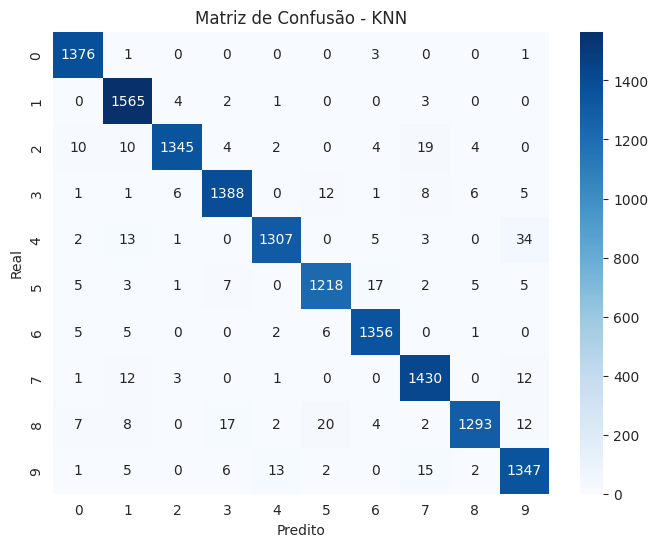

In [79]:

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - KNN')
plt.show()

In [80]:
cm_sem_diagonal = cm_knn.copy()
np.fill_diagonal(cm_sem_diagonal, 0)

indice = np.unravel_index(
    np.argmax(cm_sem_diagonal),
    cm_sem_diagonal.shape
)

digito_real = indice[0]
digito_predito = indice[1]
maior_confusao = cm_knn[indice]

print(
    f"Maior confusão: {digito_real} classificado como {digito_predito} "
    f"({maior_confusao} ocorrências)"
)

Maior confusão: 4 classificado como 9 (34 ocorrências)


## LightGBM

In [81]:
from lightgbm import LGBMClassifier


In [98]:
parametros_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2]
}



*   n_estimators É a quantidade de etapas de boosting/árvores que serão construídas.

*   learning_rate: Controla o tamanho da contribuição de cada nova árvore.






In [99]:
lgbm = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

In [100]:
lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=parametros_lgbm,
    n_iter=5,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=10
)

In [101]:
inicio = time.time()

lgbm.fit(X_train, y_train)

fim = time.time()

tempo_treinamento_lgbm = fim - inicio

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [102]:
print("Melhores hiperparâmetros:")
print(lgbm.best_params_)

print("\nMelhor acurácia na validação cruzada:")
print(lgbm.best_score_)

print("\nTempo de tunagem:")
print(f"{tempo_treinamento_lgbm / 60:.2f} minutos")

Melhores hiperparâmetros:
{'n_estimators': 300, 'learning_rate': 0.1}

Melhor acurácia na validação cruzada:
0.9808392857142858

Tempo de tunagem:
92.49 minutos


In [105]:
y_pred_lgbm = lgbm.predict(X_test)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [107]:
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)

precision_lgbm = precision_score(
    y_test,
    y_pred_lgbm,
    average='weighted'
)

recall_lgbm = recall_score(
    y_test,
    y_pred_lgbm,
    average='weighted'
)

f1_lgbm = f1_score(
    y_test,
    y_pred_lgbm,
    average='weighted'
)

print("Resultados do LightGBM:")
print(f"Accuracy:  {accuracy_lgbm:.4f}")
print(f"Precision: {precision_lgbm:.4f}")
print(f"Recall:    {recall_lgbm:.4f}")
print(f"F1-Score:  {f1_lgbm:.4f}")

Resultados do LightGBM:
Accuracy:  0.9811
Precision: 0.9812
Recall:    0.9811
F1-Score:  0.9811


In [108]:
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.99      0.98      0.98      1428
           4       0.98      0.97      0.98      1365
           5       0.99      0.98      0.98      1263
           6       0.98      0.98      0.98      1375
           7       0.98      0.98      0.98      1459
           8       0.98      0.98      0.98      1365
           9       0.97      0.97      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



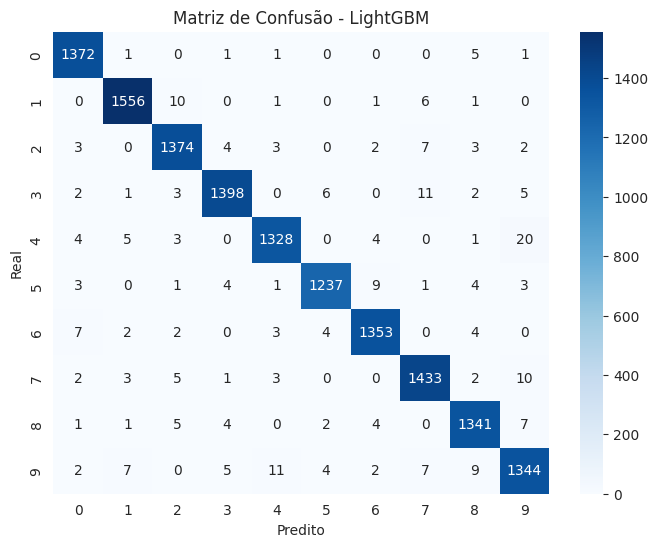

In [109]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - LightGBM')
plt.show()

In [110]:
cm_sem_diagonal = cm_lgbm.copy()
np.fill_diagonal(cm_sem_diagonal, 0)

indice = np.unravel_index(
    np.argmax(cm_sem_diagonal),
    cm_sem_diagonal.shape
)

digito_real_lgbm = indice[0]
digito_predito_lgbm = indice[1]
maior_confusao_lgbm = cm_lgbm[indice]

print(
    f"Maior confusão: {digito_real_lgbm} classificado como "
    f"{digito_predito_lgbm} ({maior_confusao_lgbm} ocorrências)"
)

Maior confusão: 4 classificado como 9 (20 ocorrências)


## MLP

In [158]:
from sklearn.model_selection import StratifiedKFold
from tensorflow import keras
from tensorflow.keras import layers

In [138]:
#Função para criar a ML
def criar_mlp(neuronios=128, learning_rate=0.001):

    modelo = keras.Sequential([
        keras.Input(shape=(784,)),

        layers.Dense(
            neuronios,
            activation='relu'
        ),

        layers.Dense(
            64,
            activation='relu'
        ),

        layers.Dense(
            10,
            activation='softmax'
        )
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

A arquitetura utilizada foi composta por duas camadas ocultas, sendo a primeira submetida à otimização do número de neurônios e a segunda mantida fixa com 64 neurônios. A camada de saída possui 10 neurônios, correspondentes às dez classes do MNIST, utilizando a função Softmax. Durante a tunagem foram ajustados dois hiperparâmetros: o número de neurônios da primeira camada oculta e a taxa de aprendizado do otimizador Adam.

In [160]:
configuracoes_mlp = [
    {'neuronios': 64,  'learning_rate': 0.0005},
    {'neuronios': 64,  'learning_rate': 0.001},
    {'neuronios': 128, 'learning_rate': 0.0005},
    {'neuronios': 128, 'learning_rate': 0.001},
    {'neuronios': 256, 'learning_rate': 0.001}
]



*   Neurônios : quantidade de neurônios  na camada oculta. Aumentar o número de neurônios aumenta a capacidade da rede de aprender relações complexas, mas também aumenta a quantidade de parâmetros e o custo computacional. Mais neurônios não significa automaticamente melhor resultado.
*   learning_rate: Controla a velocidade da taxa de aprendizado
learning_rate muito grande
→ passos grandes
→ aprende rapidamente
→ mas pode passar do ponto ideal

learning_rate muito pequeno
→ passos pequenos
→ treinamento mais estável
→ mas pode demorar mais para chegar a uma boa solução



In [161]:
#Função para tunagem dos hiperparâmetros
resultados_mlp = []

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inicio_tunagem_mlp = time.time()

total_fits = 25
fit_atual = 0

for config in configuracoes_mlp:

    neuronios = config['neuronios']
    learning_rate = config['learning_rate']

    accuracies_folds = []
    tempos_folds = []

    print(
        f"\nTestando: {neuronios} neurônios "
        f"| learning_rate = {learning_rate}"
    )

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_train, y_train),
        start=1
    ):

        fit_atual += 1

        print(
            f"Fit {fit_atual}/{total_fits} "
            f"| Fold {fold}/5"
        )

        X_train_fold = X_train[train_idx]
        y_train_fold = y_train[train_idx]

        X_val_fold = X_train[val_idx]
        y_val_fold = y_train[val_idx]

        modelo = criar_mlp(
            neuronios=neuronios,
            learning_rate=learning_rate
        )

        inicio = time.time()

        modelo.fit(
            X_train_fold,
            y_train_fold,
            epochs=10,
            batch_size=128,
            verbose=0
        )

        fim = time.time()

        tempo = fim - inicio

        probabilidades = modelo.predict(
            X_val_fold,
            verbose=0
        )

        y_pred_fold = np.argmax(
            probabilidades,
            axis=1
        )

        accuracy_fold = accuracy_score(
            y_val_fold,
            y_pred_fold
        )

        accuracies_folds.append(
            accuracy_fold
        )

        tempos_folds.append(
            tempo
        )

        print(
            f"Accuracy fold: "
            f"{accuracy_fold:.4f} "
            f"| Tempo: {tempo:.2f} s"
        )

    media_accuracy = np.mean(
        accuracies_folds
    )

    media_tempo = np.mean(
        tempos_folds
    )

    resultados_mlp.append({
        'neuronios': neuronios,
        'learning_rate': learning_rate,
        'val_accuracy': media_accuracy,
        'tempo_medio_segundos': media_tempo
    })

    print(
        f"\nAccuracy média dos 5 folds: "
        f"{media_accuracy:.4f}"
    )

    print(
        f"Tempo médio por fold: "
        f"{media_tempo:.2f} segundos\n"
    )

fim_tunagem_mlp = time.time()

tempo_tunagem_mlp = (
    fim_tunagem_mlp
    - inicio_tunagem_mlp
)


Testando: 64 neurônios | learning_rate = 0.0005
Fit 1/25 | Fold 1/5
Accuracy fold: 0.9688 | Tempo: 15.17 s
Fit 2/25 | Fold 2/5
Accuracy fold: 0.9637 | Tempo: 14.65 s
Fit 3/25 | Fold 3/5
Accuracy fold: 0.9632 | Tempo: 14.56 s
Fit 4/25 | Fold 4/5
Accuracy fold: 0.9676 | Tempo: 14.37 s
Fit 5/25 | Fold 5/5
Accuracy fold: 0.9652 | Tempo: 19.03 s

Accuracy média dos 5 folds: 0.9657
Tempo médio por fold: 15.56 segundos


Testando: 64 neurônios | learning_rate = 0.001
Fit 6/25 | Fold 1/5
Accuracy fold: 0.9725 | Tempo: 14.59 s
Fit 7/25 | Fold 2/5
Accuracy fold: 0.9683 | Tempo: 14.65 s
Fit 8/25 | Fold 3/5
Accuracy fold: 0.9654 | Tempo: 14.42 s
Fit 9/25 | Fold 4/5
Accuracy fold: 0.9679 | Tempo: 14.66 s
Fit 10/25 | Fold 5/5
Accuracy fold: 0.9665 | Tempo: 15.52 s

Accuracy média dos 5 folds: 0.9681
Tempo médio por fold: 14.77 segundos


Testando: 128 neurônios | learning_rate = 0.0005
Fit 11/25 | Fold 1/5
Accuracy fold: 0.9737 | Tempo: 18.52 s
Fit 12/25 | Fold 2/5
Accuracy fold: 0.9704 | Tempo: 20

In [165]:
df_resultados_mlp = pd.DataFrame(
    resultados_mlp
)

df_resultados_mlp = (
    df_resultados_mlp
    .sort_values(
        by='val_accuracy',
        ascending=False
    )
)

df_resultados_mlp

,neuronios,learning_rate,val_accuracy,tempo_medio_segundos
4,256,0.0010,0.976036,28.751291
3,128,0.0010,0.973250,19.672617
2,128,0.0005,0.972446,20.443832
1,64,0.0010,0.968125,14.770206
0,64,0.0005,0.965714,15.557020


In [166]:
melhor_config = df_resultados_mlp.iloc[0]

melhor_neuronios = int(
    melhor_config['neuronios']
)

melhor_learning_rate = float(
    melhor_config['learning_rate']
)

print(
    "Melhor número de neurônios:",
    melhor_neuronios
)

print(
    "Melhor learning rate:",
    melhor_learning_rate
)

Melhor número de neurônios: 256
Melhor learning rate: 0.001


In [167]:
mlp_final = criar_mlp(
    neuronios=melhor_neuronios,
    learning_rate=melhor_learning_rate
)

In [168]:
inicio = time.time()

history_final = mlp_final.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    verbose=1
)

fim = time.time()

tempo_fit_mlp = fim - inicio

print(
    f"Tempo de treinamento final: "
    f"{tempo_fit_mlp:.2f} segundos"
)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9171 - loss: 0.2919
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9667 - loss: 0.1123
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9769 - loss: 0.0749
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9832 - loss: 0.0549
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9877 - loss: 0.0402
Epoch 6/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9912 - loss: 0.0290
Epoch 7/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9928 - loss: 0.0237
Epoch 8/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9940 - loss: 0.0196
Epoch 9/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9957 - loss: 0.0150
Epoch 10/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9963 - loss: 0.0114
Tempo de treinamento final: 43.57 segundos


In [169]:
probabilidades_mlp = mlp_final.predict(
    X_test,
    verbose=0
)

In [170]:
y_pred_mlp = np.argmax(
    probabilidades_mlp,
    axis=1
)

In [171]:
accuracy_mlp = accuracy_score(
    y_test,
    y_pred_mlp
)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp,
    average='weighted'
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp,
    average='weighted'
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp,
    average='weighted'
)

In [172]:
print("Resultados do MLP:")

print(
    f"Accuracy:  {accuracy_mlp:.4f}"
)

print(
    f"Precision: {precision_mlp:.4f}"
)

print(
    f"Recall:    {recall_mlp:.4f}"
)

print(
    f"F1-Score:  {f1_mlp:.4f}"
)

Resultados do MLP:
Accuracy:  0.9773
Precision: 0.9775
Recall:    0.9773
F1-Score:  0.9773


In [173]:
print(
    classification_report(
        y_test,
        y_pred_mlp
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.98      0.97      0.98      1428
           4       0.99      0.97      0.98      1365
           5       0.95      0.99      0.97      1263
           6       0.99      0.99      0.99      1375
           7       0.95      0.99      0.97      1459
           8       0.98      0.96      0.97      1365
           9       0.98      0.95      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



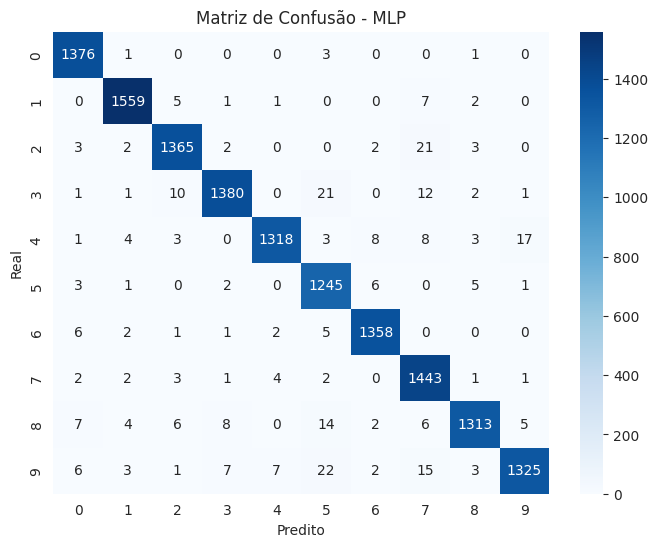

In [174]:
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predito')
plt.ylabel('Real')

plt.title(
    'Matriz de Confusão - MLP'
)

plt.show()

In [175]:
cm_sem_diagonal = cm_mlp.copy()

np.fill_diagonal(
    cm_sem_diagonal,
    0
)

indice = np.unravel_index(
    np.argmax(cm_sem_diagonal),
    cm_sem_diagonal.shape
)

digito_real_mlp = indice[0]

digito_predito_mlp = indice[1]

maior_confusao_mlp = (
    cm_mlp[indice]
)

print(
    f"Maior confusão: "
    f"{digito_real_mlp} classificado como "
    f"{digito_predito_mlp} "
    f"({maior_confusao_mlp} ocorrências)"
)

Maior confusão: 9 classificado como 5 (22 ocorrências)


In [176]:
print(
    f"Tempo total de tunagem do MLP: "
    f"{tempo_tunagem_mlp / 60:.2f} minutos"
)

Tempo total de tunagem do MLP: 8.68 minutos


## Resultados final

In [178]:
resultados_finais = pd.DataFrame([
    {
        'Modelo': 'KNN',
        'Tempo tunagem (min)': tempo_treinamento_knn / 60,
        'Accuracy': accuracy_knn,
        'Precision': precision_knn,
        'Recall': recall_knn,
        'F1-Score': f1_knn
    },

    {
        'Modelo': 'LightGBM',
        'Tempo tunagem (min)': tempo_treinamento_lgbm / 60,
        'Accuracy': accuracy_lgbm,
        'Precision': precision_lgbm,
        'Recall': recall_lgbm,
        'F1-Score': f1_lgbm
    },

    {
        'Modelo': 'MLP',
        'Tempo tunagem (min)': tempo_tunagem_mlp / 60,
        'Accuracy': accuracy_mlp,
        'Precision': precision_mlp,
        'Recall': recall_mlp,
        'F1-Score': f1_mlp
    }
])

resultados_finais = resultados_finais.round({
    'Tempo tunagem (min)': 2,
    'Tempo predict (s)': 2,
    'Accuracy': 4,
    'Precision': 4,
    'Recall': 4,
    'F1-Score': 4
})

resultados_finais

,Modelo,Tempo tunagem (min),Accuracy,Precision,Recall,F1-Score
0,KNN,14.47,0.9732,0.9734,0.9732,0.9732
1,LightGBM,92.49,0.9811,0.9812,0.9811,0.9811
2,MLP,8.68,0.9773,0.9775,0.9773,0.9773






*   MLP foi o mais rápido e foi o segundo melhor no geral 98,11% − 97,73% = 0,38 p.p no f1-score comparado com o melhor o LightGBM
*   O LightGBM levou aproximadamente 10,7 vezes mais tempo para a tunagem: 92,49 / 8,68 ≈ 10,7. Também comparado com o LightGBM






# 4 Testando a capacidade do modelo MLP de lidar com cenários fora do padrão ideal de laboratório:


Nessa sessão irá ser retirado os dígitos 4 e 7 e irá ser treinado novo modelo com essa base, após isso será testado esse modelo com uma base contendo apenas 4 e 7

In [179]:
classes_ocultas = [4, 7]

mascara_treino = ~np.isin(y_train, classes_ocultas)

X_train_masked = X_train[mascara_treino]
y_train_masked = y_train[mascara_treino]

In [191]:
print(np.unique(y_train_masked))

[0 1 2 3 5 6 8 9]


Após a verifiação das classes ocultas o treinamento do MLP vai ser parecido com a parte anterior

In [192]:
def criar_mlp_masked(
    neuronios=128,
    learning_rate=0.001
):

    modelo = keras.Sequential([
        keras.Input(shape=(784,)),

        layers.Dense(
            neuronios,
            activation='relu'
        ),

        layers.Dense(
            64,
            activation='relu'
        ),

        layers.Dense(
            10,
            activation='softmax'
        )
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [193]:
configuracoes_mlp_masked = [
    {'neuronios': 64,  'learning_rate': 0.0005},
    {'neuronios': 64,  'learning_rate': 0.001},
    {'neuronios': 128, 'learning_rate': 0.0005},
    {'neuronios': 128, 'learning_rate': 0.001},
    {'neuronios': 256, 'learning_rate': 0.001}
]

In [194]:
resultados_mlp_masked = []

skf_masked = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inicio_tunagem_mlp_masked = time.time()

total_fits_masked = (
    len(configuracoes_mlp_masked) * 5
)

fit_atual_masked = 0


for config in configuracoes_mlp_masked:

    neuronios = config['neuronios']
    learning_rate = config['learning_rate']

    accuracies_folds_masked = []
    tempos_folds_masked = []

    print(
        f"\nTestando: {neuronios} neurônios "
        f"| learning_rate = {learning_rate}"
    )

    for fold, (train_idx, val_idx) in enumerate(
        skf_masked.split(
            X_train_masked,
            y_train_masked
        ),
        start=1
    ):

        fit_atual_masked += 1

        print(
            f"Fit {fit_atual_masked}/"
            f"{total_fits_masked} "
            f"| Fold {fold}/5"
        )

        X_train_fold_masked = (
            X_train_masked[train_idx]
        )

        y_train_fold_masked = (
            y_train_masked[train_idx]
        )

        X_val_fold_masked = (
            X_train_masked[val_idx]
        )

        y_val_fold_masked = (
            y_train_masked[val_idx]
        )

        modelo_fold_masked = criar_mlp_masked(
            neuronios=neuronios,
            learning_rate=learning_rate
        )

        inicio_fold = time.time()

        modelo_fold_masked.fit(
            X_train_fold_masked,
            y_train_fold_masked,
            epochs=10,
            batch_size=128,
            verbose=0
        )

        fim_fold = time.time()

        tempo_fold = (
            fim_fold - inicio_fold
        )

        probabilidades_fold_masked = (
            modelo_fold_masked.predict(
                X_val_fold_masked,
                verbose=0
            )
        )

        y_pred_fold_masked = np.argmax(
            probabilidades_fold_masked,
            axis=1
        )

        accuracy_fold_masked = accuracy_score(
            y_val_fold_masked,
            y_pred_fold_masked
        )

        accuracies_folds_masked.append(
            accuracy_fold_masked
        )

        tempos_folds_masked.append(
            tempo_fold
        )

        print(
            f"Accuracy fold: "
            f"{accuracy_fold_masked:.4f} "
            f"| Tempo: "
            f"{tempo_fold:.2f} s"
        )

    media_accuracy_masked = np.mean(
        accuracies_folds_masked
    )

    media_tempo_masked = np.mean(
        tempos_folds_masked
    )

    resultados_mlp_masked.append({

        'neuronios': neuronios,

        'learning_rate':
            learning_rate,

        'val_accuracy':
            media_accuracy_masked,

        'tempo_medio_segundos':
            media_tempo_masked
    })

    print(
        f"\nAccuracy média dos 5 folds: "
        f"{media_accuracy_masked:.4f}"
    )

    print(
        f"Tempo médio por fold: "
        f"{media_tempo_masked:.2f} segundos\n"
    )


fim_tunagem_mlp_masked = time.time()

tempo_tunagem_mlp_masked = (
    fim_tunagem_mlp_masked
    - inicio_tunagem_mlp_masked
)

print(
    "Tempo total da tunagem:",
    round(
        tempo_tunagem_mlp_masked / 60,
        2
    ),
    "minutos"
)


Testando: 64 neurônios | learning_rate = 0.0005
Fit 1/25 | Fold 1/5
Accuracy fold: 0.9732 | Tempo: 12.71 s
Fit 2/25 | Fold 2/5
Accuracy fold: 0.9713 | Tempo: 14.53 s
Fit 3/25 | Fold 3/5
Accuracy fold: 0.9722 | Tempo: 13.71 s
Fit 4/25 | Fold 4/5
Accuracy fold: 0.9725 | Tempo: 19.87 s
Fit 5/25 | Fold 5/5
Accuracy fold: 0.9725 | Tempo: 21.87 s

Accuracy média dos 5 folds: 0.9723
Tempo médio por fold: 16.54 segundos


Testando: 64 neurônios | learning_rate = 0.001
Fit 6/25 | Fold 1/5
Accuracy fold: 0.9765 | Tempo: 13.45 s
Fit 7/25 | Fold 2/5
Accuracy fold: 0.9738 | Tempo: 20.35 s
Fit 8/25 | Fold 3/5
Accuracy fold: 0.9720 | Tempo: 13.27 s
Fit 9/25 | Fold 4/5
Accuracy fold: 0.9758 | Tempo: 13.19 s
Fit 10/25 | Fold 5/5
Accuracy fold: 0.9762 | Tempo: 12.89 s

Accuracy média dos 5 folds: 0.9749
Tempo médio por fold: 14.63 segundos


Testando: 128 neurônios | learning_rate = 0.0005
Fit 11/25 | Fold 1/5
Accuracy fold: 0.9779 | Tempo: 15.49 s
Fit 12/25 | Fold 2/5
Accuracy fold: 0.9755 | Tempo: 15

In [195]:
df_resultados_mlp_masked = pd.DataFrame(
    resultados_mlp_masked
).sort_values(
    by='val_accuracy',
    ascending=False
)

df_resultados_mlp_masked

,neuronios,learning_rate,val_accuracy,tempo_medio_segundos
4,256,0.0010,0.978661,24.381872
3,128,0.0010,0.977498,16.098927
2,128,0.0005,0.975865,16.162335
1,64,0.0010,0.974881,14.631913
0,64,0.0005,0.972309,16.538761


In [196]:
melhor_config_masked = (
    df_resultados_mlp_masked.iloc[0]
)

melhor_neuronios_masked = int(
    melhor_config_masked['neuronios']
)

melhor_learning_rate_masked = float(
    melhor_config_masked['learning_rate']
)

print(
    "Melhor número de neurônios:",
    melhor_neuronios_masked
)

print(
    "Melhor learning rate:",
    melhor_learning_rate_masked
)

print(
    "Melhor accuracy média CV:",
    melhor_config_masked['val_accuracy']
)

Melhor número de neurônios: 256
Melhor learning rate: 0.001
Melhor accuracy média CV: 0.9786609731715987


In [197]:
mlp_final_masked = criar_mlp_masked(
    neuronios=melhor_neuronios_masked,
    learning_rate=melhor_learning_rate_masked
)

In [198]:
mlp_final_masked = criar_mlp_masked(
    neuronios=melhor_neuronios_masked,
    learning_rate=melhor_learning_rate_masked
)

In [199]:
mascara_ood = np.isin(
    y_test,
    classes_ocultas
)

X_test_ood = X_test[mascara_ood]
y_test_ood = y_test[mascara_ood]

print(
    "Formato do conjunto OOD:",
    X_test_ood.shape
)

print(
    "Classes presentes no OOD:",
    np.unique(y_test_ood)
)

Formato do conjunto OOD: (2824, 784)
Classes presentes no OOD: [4 7]


In [201]:
probabilidades_ood = mlp_final_masked.predict(
    X_test_ood,
    verbose=0
)

In [202]:
y_pred_ood = np.argmax(
    probabilidades_ood,
    axis=1
)

In [203]:
confianca_ood = np.max(
    probabilidades_ood,
    axis=1
)

In [204]:
classes_preditas_ood, contagens_ood = (
    np.unique(
        y_pred_ood,
        return_counts=True
    )
)

for classe, quantidade in zip(
    classes_preditas_ood,
    contagens_ood
):

    print(
        f"Classe {classe}: "
        f"{quantidade} previsões"
    )

Classe 0: 473 previsões
Classe 1: 81 previsões
Classe 2: 1282 previsões
Classe 3: 9 previsões
Classe 4: 77 previsões
Classe 5: 120 previsões
Classe 7: 54 previsões
Classe 8: 676 previsões
Classe 9: 52 previsões


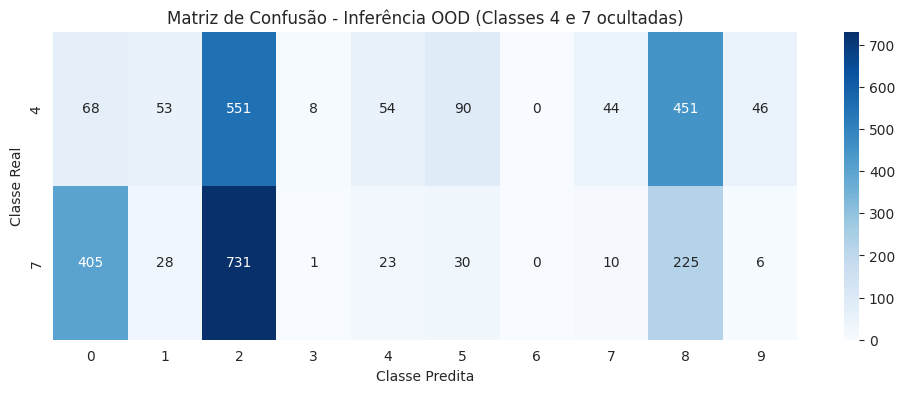

In [206]:
matriz_ood = pd.crosstab(
    y_test_ood,
    y_pred_ood
)

matriz_ood = matriz_ood.reindex(
    index=[4, 7],
    columns=range(10),
    fill_value=0
)

plt.figure(figsize=(12, 4))

sns.heatmap(
    matriz_ood,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')

plt.title(
    'Matriz de Confusão - Inferência OOD '
    '(Classes 4 e 7 ocultadas)'
)

plt.show()

In [208]:
print(
    "Confiança média:",
    round(confianca_ood.mean(), 4)
)

print(
    "Confiança mínima:",
    round(confianca_ood.min(), 4)
)

print(
    "Confiança máxima:",
    round(confianca_ood.max(), 4)
)

print(
    "Mediana da confiança:",
    round(np.median(confianca_ood), 4)
)

percentual_acima_90 = (
    np.mean(confianca_ood >= 0.90) * 100
)

percentual_acima_95 = (
    np.mean(confianca_ood >= 0.95) * 100
)

print(
    f"Previsões com confiança >= 90%: "
    f"{percentual_acima_90:.2f}%"
)

print(
    f"Previsões com confiança >= 95%: "
    f"{percentual_acima_95:.2f}%"
)

Confiança média: 0.1547
Confiança mínima: 0.1074
Confiança máxima: 0.3339
Mediana da confiança: 0.1476
Previsões com confiança >= 90%: 0.00%
Previsões com confiança >= 95%: 0.00%


Na inferência de 4 e 7 , o modelo foi obrigado a atribuir os dígitos ocultados a alguma das classes disponíveis, apresentando maior tendência de classificá-los como os dígitos 2, 8 e 0. Entretanto, não foi observado um comportamento acentuado de falsa certeza. A confiança média das previsões foi de apenas 15,47%, com mediana de 14,76% e confiança máxima de 33,39%. Nenhuma previsão apresentou confiança superior a 90%. Esses resultados indicam que, embora o classificador seja incapaz de representar explicitamente a resposta "classe desconhecida", sua distribuição Softmax permaneceu relativamente dispersa diante das amostras desconhecidas, demonstrando incerteza nas classificações realizadas.

A falsa certeza (overconfidence) ocorre quando um modelo atribui probabilidades elevadas a previsões incorretas, inclusive diante de dados diferentes daqueles observados durante o treinamento. Embora redes neurais possam apresentar esse comportamento, ele não foi intenso neste experimento. Ainda assim, o modelo sempre retorna uma das classes disponíveis, mesmo quando nenhuma delas corresponde adequadamente à entrada, mostrando que a probabilidade Softmax não deve ser interpretada automaticamente como uma medida confiável de conhecimento do modelo.

# 5 Desenhando e prevendo

Nessa sessão irei upar um 5 desenhando por mim no paint para realizar previsão  nele

In [209]:
from PIL import Image, ImageOps

In [239]:
imagem = Image.open("/content/meu 5.PNG").convert('L')

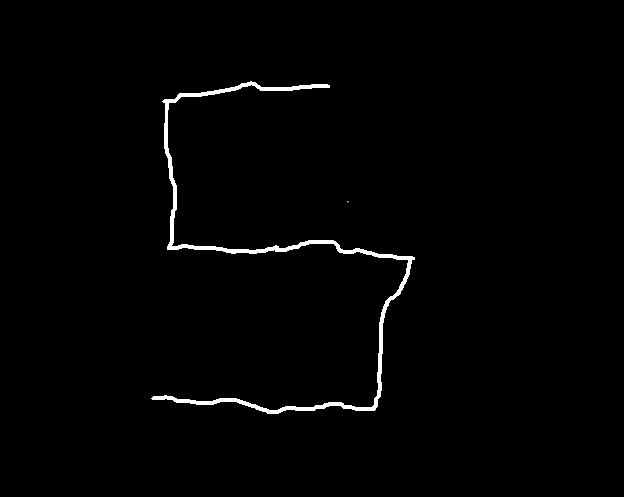

In [240]:
imagem

In [247]:
# Preservar o traço original
traco = imagem.copy()

# Redimensionar o traço para no máximo 20x20
traco.thumbnail(
    (20, 20),
    Image.Resampling.LANCZOS
)

# Criar tela preta 28x28
imagem_mnist = Image.new(
    'L',
    (28, 28),
    color=0
)

# Calcular posição para centralizar O TRAÇO
pos_x = (28 - traco.width) // 2
pos_y = (28 - traco.height) // 2

# Colar o traço na tela 28x28
imagem_mnist.paste(
    traco,
    (pos_x, pos_y)
)

# Normalizar
dados_imagem = np.array(
    imagem_mnist
) / 255.0

# Formato esperado pelo KNN
dados_prontos = dados_imagem.reshape(
    1,
    784
)

In [248]:
# Probabilidades por classe
probabilidades_knn = knn.predict_proba(dados_prontos)

# Índice da classe com maior probabilidade
indice_predicao_knn = np.argmax(probabilidades_knn[0])

# Classe correspondente
predicao_knn = knn.classes_[indice_predicao_knn]

# Confiança
certeza_knn = probabilidades_knn[0][indice_predicao_knn] * 100


O modelo KNN identificou o número: 1
Confiança: 100.00%



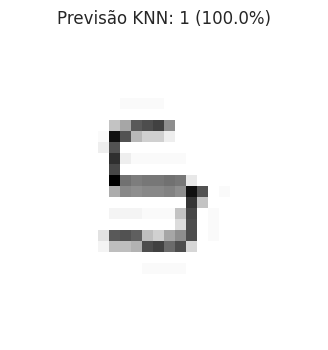

In [249]:
print(f"\nO modelo KNN identificou o número: {predicao_knn}")
print(f"Confiança: {certeza_knn:.2f}%\n")

plt.figure(figsize=(4, 4))

plt.imshow(
    dados_imagem,
    cmap='binary'
)

plt.title(
    f"Previsão KNN: {predicao_knn} "
    f"({certeza_knn:.1f}%)"
)

plt.axis('off')
plt.show()


O modelo LightGBM identificou o número: 7
Confiança: 60.44%



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


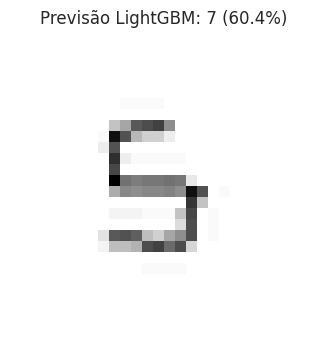

In [250]:
# Probabilidades por classe
probabilidades_lgbm = lgbm.predict_proba(dados_prontos)

# Índice da classe com maior probabilidade
indice_predicao_lgbm = np.argmax(probabilidades_lgbm[0])

# Classe correspondente
predicao_lgbm = lgbm.classes_[indice_predicao_lgbm]

# Confiança
certeza_lgbm = (
    probabilidades_lgbm[0][indice_predicao_lgbm]
    * 100
)

print(
    f"\nO modelo LightGBM identificou o número: "
    f"{predicao_lgbm}"
)

print(
    f"Confiança: {certeza_lgbm:.2f}%\n"
)

plt.figure(figsize=(4, 4))

plt.imshow(
    dados_imagem,
    cmap='binary'
)

plt.title(
    f"Previsão LightGBM: {predicao_lgbm} "
    f"({certeza_lgbm:.1f}%)"
)

plt.axis('off')
plt.show()


O modelo MLP identificou o número: 5
Confiança: 30.17%



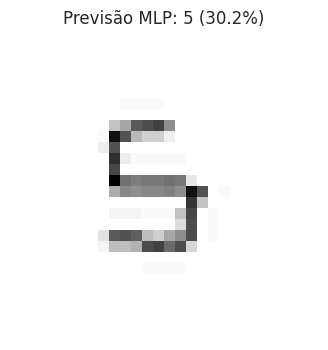

In [251]:
# Probabilidades por classe
probabilidades_mlp = mlp_final.predict(
    dados_prontos,
    verbose=0
)

# Índice com maior probabilidade
predicao_mlp = np.argmax(
    probabilidades_mlp[0]
)

# Confiança
certeza_mlp = (
    probabilidades_mlp[0][predicao_mlp]
    * 100
)

print(
    f"\nO modelo MLP identificou o número: "
    f"{predicao_mlp}"
)

print(
    f"Confiança: {certeza_mlp:.2f}%\n"
)

plt.figure(figsize=(4, 4))

plt.imshow(
    dados_imagem,
    cmap='binary'
)

plt.title(
    f"Previsão MLP: {predicao_mlp} "
    f"({certeza_mlp:.1f}%)"
)

plt.axis('off')
plt.show()